In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore

In [64]:
df_full = pd.read_csv('../data/processed/dataset.csv').drop(columns=['Unnamed: 0'])

In [65]:
df_full

,datetime,speed,power,price,load
0,2020-01-01 01:00:00,7.194702,10827.38,13.6875,1172.943179
1,2020-01-01 02:00:00,7.516418,11527.36,13.2450,1165.951313
2,2020-01-01 03:00:00,7.272845,12100.85,11.3500,1149.076769
3,2020-01-01 04:00:00,7.192857,12780.48,9.3925,1141.301918
4,2020-01-01 05:00:00,7.382434,13064.80,8.6050,1147.094161
...,...,...,...,...,...
43843,2024-12-31 20:00:00,3.905590,2678.47,50.1650,1220.123968
43844,2024-12-31 21:00:00,3.856292,4396.05,31.5675,1224.000675
43845,2024-12-31 22:00:00,3.379553,5852.33,26.8350,1216.576523
43846,2024-12-31 23:00:00,3.468478,7239.34,22.4650,1216.686183


In [66]:
df_full.describe()

,speed,power,price,load
count,42015.000000,43835.000000,43842.000000,43848.000000
mean,7.403859,8203.081693,67.220145,1273.762099
std,3.111718,6387.509535,454.293170,261.372656
min,0.090284,7.410000,-31.720000,735.793806
25%,5.157909,3786.940000,13.878125,1089.936387
50%,7.401488,7852.350000,23.285000,1205.091111
75%,9.563989,12332.465000,45.886875,1404.222268
max,20.047289,257825.280000,9198.255000,2230.497660


Text(0, 0.5, 'Power Output (MW)')

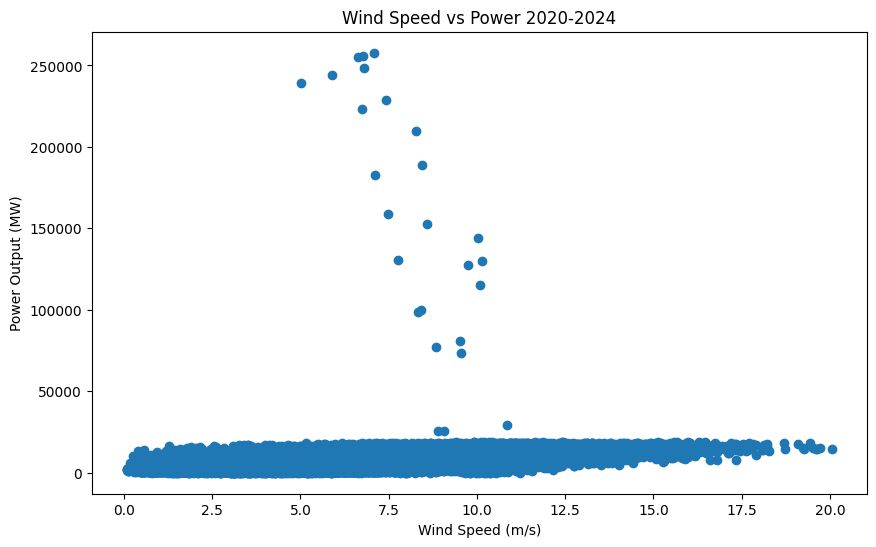

In [67]:
plt.figure(figsize=(10, 6))
plt.scatter(df_full['speed'], df_full['power'])
plt.title('Wind Speed vs Power 2020-2024')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power Output (MW)')

## Power outliers

In [68]:
df_full['power'].sort_values(ascending=False).head(30)

40682    257825.28
40681    255853.60
40701    254959.84
40683    248529.92
40680    244179.04
40678    242315.84
40679    239110.56
40684    229039.84
40700    223525.92
40685    209578.56
40686    188983.68
40699    182718.88
40698    159118.72
40687    152521.12
40690    144353.60
40697    130643.20
40689    130208.64
40691    127282.56
40688    115185.44
40696     99641.28
40692     98626.24
40695     80683.04
40693     77260.48
40694     73544.48
1608      29359.56
24871     25867.38
28765     25711.49
39141     18981.92
39140     18977.86
39116     18920.98
Name: power, dtype: float64

In [69]:
powers = df_full['power'].dropna()
zscores = zscore(powers)
outliers = abs(zscores) > 2.5
powers = powers[outliers]
print(len(powers))
powers

27


1608      29359.56
24871     25867.38
28765     25711.49
40678    242315.84
40679    239110.56
40680    244179.04
40681    255853.60
40682    257825.28
40683    248529.92
40684    229039.84
40685    209578.56
40686    188983.68
40687    152521.12
40688    115185.44
40689    130208.64
40690    144353.60
40691    127282.56
40692     98626.24
40693     77260.48
40694     73544.48
40695     80683.04
40696     99641.28
40697    130643.20
40698    159118.72
40699    182718.88
40700    223525.92
40701    254959.84
Name: power, dtype: float64

In [70]:
df_full[df_full['power'] > 20000]

,datetime,speed,power,price,load
1608,2020-03-08 01:00:00,10.852813,29359.56,-1.9750,1043.747372
24871,2022-11-02 09:00:00,8.885884,25867.38,29.2500,1094.104121
28765,2023-04-13 15:00:00,9.071159,25711.49,5.5075,1244.109036
40678,2024-08-21 24:00:00,NaN,242315.84,24.4400,1703.363542
40679,2024-08-22 01:00:00,5.017566,239110.56,26.7675,1577.730713
40680,2024-08-22 02:00:00,5.883522,244179.04,18.3125,1494.057044
40681,2024-08-22 03:00:00,6.780171,255853.60,16.7525,1429.797147
40682,2024-08-22 04:00:00,7.089714,257825.28,16.1000,1385.560362
40683,2024-08-22 05:00:00,6.806499,248529.92,15.4775,1351.137602
40684,2024-08-22 06:00:00,7.418423,229039.84,16.9125,1349.980540


## NaN Values

In [71]:
df_full.isna().sum()

datetime       0
speed       1833
power         13
price          6
load           0
dtype: int64

In [72]:
# split data by year
df20 = df_full.iloc[0:8784]
df21 = df_full.iloc[8784:17544]
df22 = df_full.iloc[17544:26304]
df23 = df_full.iloc[26304:35064]
df24 = df_full.iloc[35064:]
df1mo = df_full.iloc[0:720]

In [73]:
df20[df20['speed'].isna()]

,datetime,speed,power,price,load
23,2020-01-01 24:00:00,NaN,13095.39,14.8675,1162.998553
47,2020-01-02 24:00:00,NaN,9248.17,18.3575,1133.636729
71,2020-01-03 24:00:00,NaN,3732.66,19.5625,1266.669492
95,2020-01-04 24:00:00,NaN,13669.30,1.7200,1179.229120
119,2020-01-05 24:00:00,NaN,4222.64,14.5825,1105.549848
...,...,...,...,...,...
8687,2020-12-27 24:00:00,NaN,10442.42,16.8475,984.297074
8711,2020-12-28 24:00:00,NaN,11602.91,15.7250,960.449008
8735,2020-12-29 24:00:00,NaN,9622.37,15.3050,944.554943
8759,2020-12-30 24:00:00,NaN,9304.99,15.6225,1295.022035


In [74]:
df_full[df_full['speed'].isna()]

,datetime,speed,power,price,load
23,2020-01-01 24:00:00,NaN,13095.39,14.8675,1162.998553
47,2020-01-02 24:00:00,NaN,9248.17,18.3575,1133.636729
71,2020-01-03 24:00:00,NaN,3732.66,19.5625,1266.669492
95,2020-01-04 24:00:00,NaN,13669.30,1.7200,1179.229120
119,2020-01-05 24:00:00,NaN,4222.64,14.5825,1105.549848
...,...,...,...,...,...
43751,2024-12-27 24:00:00,NaN,12251.78,17.3350,1115.793423
43775,2024-12-28 24:00:00,NaN,2849.25,59.7025,1114.488267
43799,2024-12-29 24:00:00,NaN,17883.48,15.4175,1071.477479
43823,2024-12-30 24:00:00,NaN,16329.49,59.7450,1083.771968


In [75]:
df_full[df_full['power'].isna() & df_full['speed'].isna() & df_full['price'].isna()]

,datetime,speed,power,price,load
7321,2020-11-01 02:00 DST:00,NaN,NaN,NaN,921.288740
16225,2021-11-07 02:00 DST:00,NaN,NaN,NaN,914.756279
24961,2022-11-06 02:00 DST:00,NaN,NaN,NaN,938.180082
25560,2-01-20-2- 01:00:00:00,NaN,NaN,NaN,1263.720051
33697,2023-11-05 02:00 DST:00,NaN,NaN,NaN,952.353719
42433,2024-11-03 02:00 DST:00,NaN,NaN,NaN,1046.335622


## After dropping NaNs and power outliers

In [76]:
# dropping NaNs and unusual power values
df = df_full.dropna().reset_index(drop=True)
df = df[df['power'] < 20000].reset_index(drop=True)

In [80]:
# re-split data by year
df20 = df.iloc[0:8415]
df21 = df.iloc[8415:16808]
df22 = df.iloc[16808:25199]
df23 = df.iloc[25199:33590]
df24 = df.iloc[33590:]
df1mo = df.iloc[0:713]

Text(0, 0.5, 'Power Output (MW)')

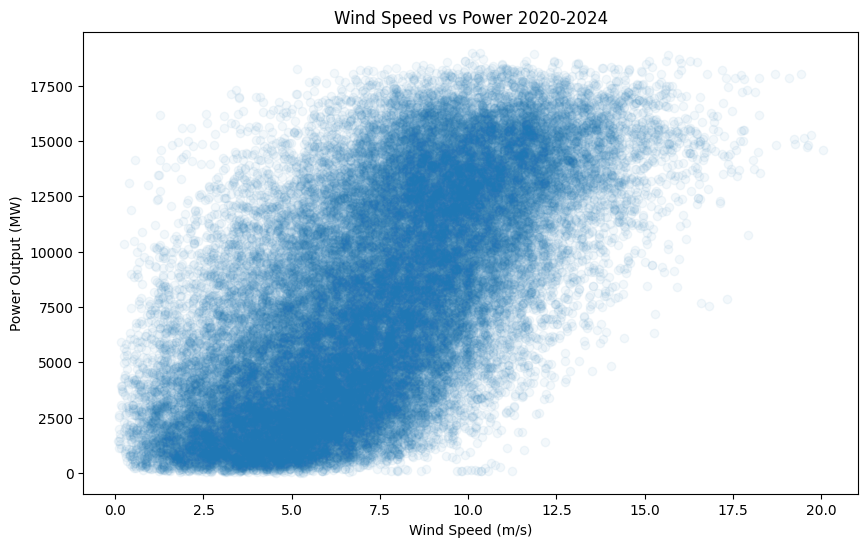

In [82]:
plt.figure(figsize=(10, 6))
plt.scatter(df['speed'], df['power'], alpha=0.05)
plt.title('Wind Speed vs Power 2020-2024')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power Output (MW)')

Text(0, 0.5, 'Power Output (MW)')

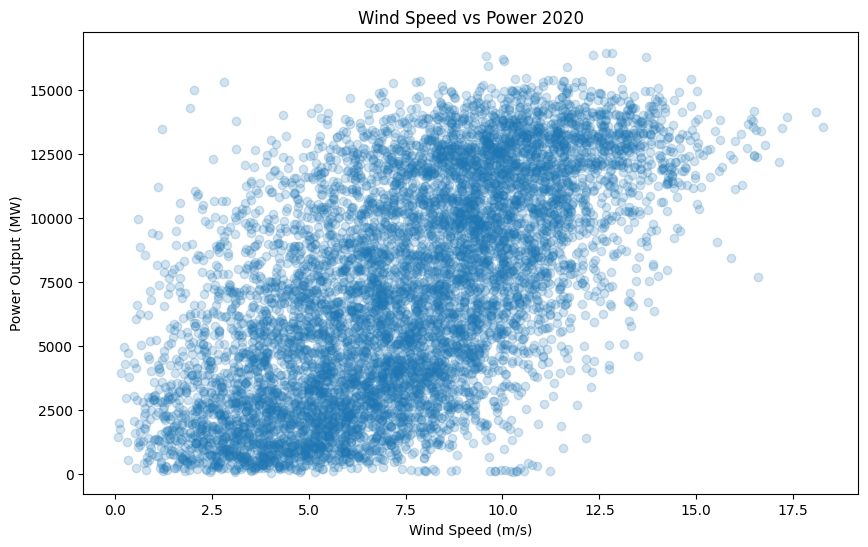

In [81]:
plt.figure(figsize=(10, 6))
plt.scatter(df20['speed'], df20['power'], alpha=0.2, label='Data Points')
plt.title('Wind Speed vs Power 2020')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power Output (MW)')

## Comparing ERA5 and Pluswind wind speeds

In [6]:
df = pd.read_csv('../data/processed/dataset_2018-21.csv')
data = pd.read_csv('../data/processed/dataset.csv', index_col=0)

In [7]:
# 2020-2021 speeds normalized
era5 = (data['speed'][:17543] / np.max(data['speed'][:17543])).reset_index(drop=True)
pluswind = (df['speed_HRRR'][17521:] / np.max(df['speed_HRRR'][17521:])).reset_index(drop=True)
combined = pd.DataFrame({'era5': era5, 'pluswind': pluswind}).dropna()

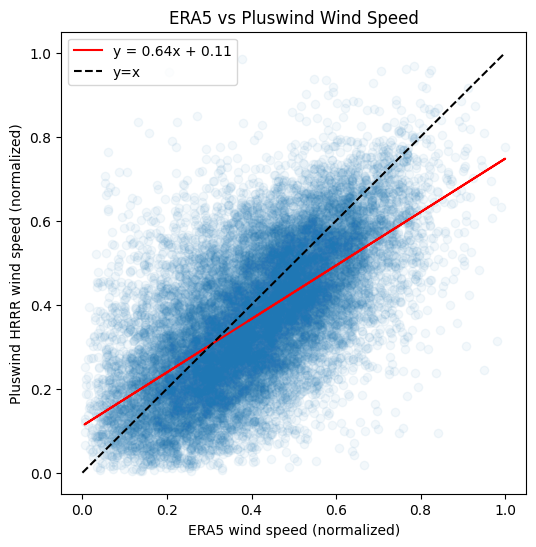

In [8]:
plt.figure(figsize=(6, 6))
plt.scatter(combined['era5'], combined['pluswind'], alpha=0.05)

# line of best fit
m, b = np.polyfit(combined['era5'], combined['pluswind'], 1)
reg = m * combined['era5'] + b
eq_label = f'y = {m:.2f}x + {b:.2f}'
plt.plot(combined['era5'], reg, color='red', label=eq_label)

plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='y=x')

plt.xlabel('ERA5 wind speed (normalized)')
plt.ylabel('Pluswind HRRR wind speed (normalized)')
plt.title('ERA5 vs Pluswind Wind Speed')
plt.legend()
plt.show()

## Simulated Power vs PLUSWIND Wind Speeds

In [9]:
df_pluswind = pd.read_csv('../data/processed/dataset_2018-21.csv')
pyron = pd.read_csv('../data/processed/pyron_power.csv')

In [10]:
df_pluswind['pyron_power'] = pyron['Power']

In [11]:
df_pluswind

,datetime,speed_HRRR,power_cf,lmp,pyron_power
0,2018-01-01 00:00:00,7.099200,0.267882,27.688333,106.861
1,2018-01-01 01:00:00,6.384246,0.191033,27.721667,97.278
2,2018-01-01 02:00:00,6.679563,0.220842,27.409167,94.380
3,2018-01-01 03:00:00,6.784414,0.232067,27.933333,84.472
4,2018-01-01 04:00:00,6.794198,0.233133,28.816667,72.284
...,...,...,...,...,...
35059,2021-12-31 19:00:00,NaN,NaN,23.387692,75.361
35060,2021-12-31 20:00:00,NaN,NaN,35.808333,125.721
35061,2021-12-31 21:00:00,NaN,NaN,37.739167,127.743
35062,2021-12-31 22:00:00,NaN,NaN,60.945833,66.863


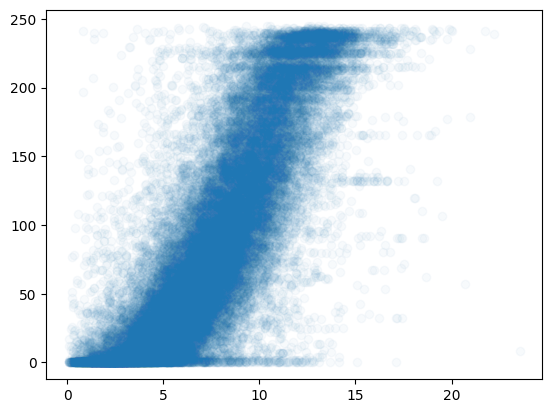

In [12]:
plt.scatter(df_pluswind['speed_HRRR'], df_pluswind['pyron_power'], alpha=0.03)